<a href="https://colab.research.google.com/github/Gael199/Final_Projet/blob/master/TP1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Question 1 :

In [12]:
def generate_data(n= 500, alpha=0.9, beta=0.1):
  X = np.random.uniform(0,1, (n,2))
  cond = np.abs(X[:,0]+2*X[:,1]) <=1
  probs = np.where(cond, alpha, beta)
  Y = (np.random.rand(n)<probs).astype(int)
  return X,Y


In [16]:
X, Y = generate_data(n=500, alpha=0.9, beta=0.9)
print("proportion de Y=1 :", Y.mean())

proportion de Y=1 : 0.924


In [17]:
# Question 2 :

In [18]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1)
print("Taille train :", X_train.shape[0], "Taille test :", X_test.shape[0])

Taille train : 400 Taille test : 100


In [21]:
# Question 3 :

In [22]:
import seaborn as sns

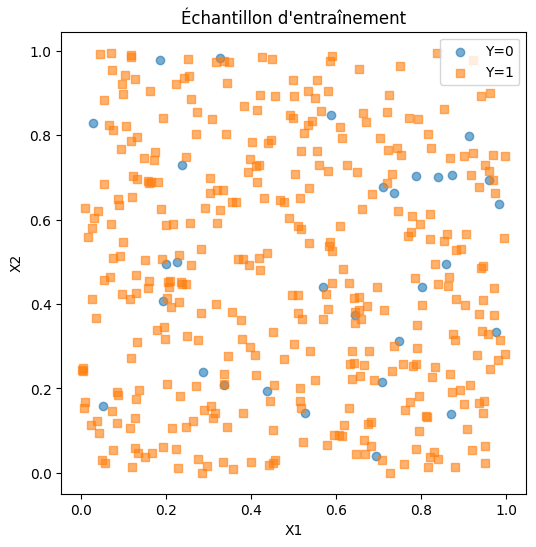

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
for label, marker in zip([0, 1], ["o", "s"]):
    idx = y_train == label
    ax.scatter(X_train[idx, 0], X_train[idx, 1], marker=marker, label=f"Y={label}", alpha=0.6)
ax.set_title("Échantillon d'entraînement")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.legend()
plt.show()

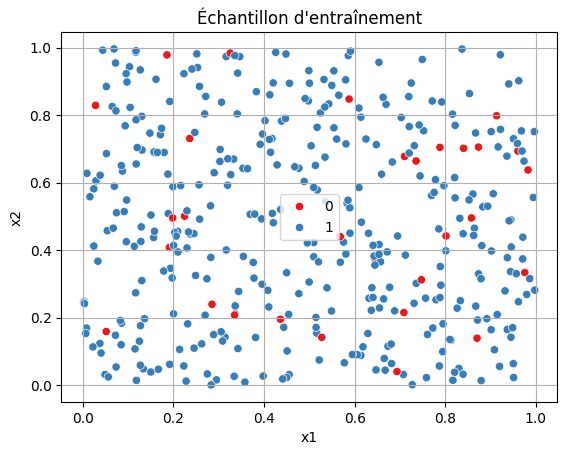

In [26]:
sns.scatterplot(x=X_train[:,0], y=X_train[:,1], hue=y_train, palette='Set1')
plt.title("Échantillon d'entraînement")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

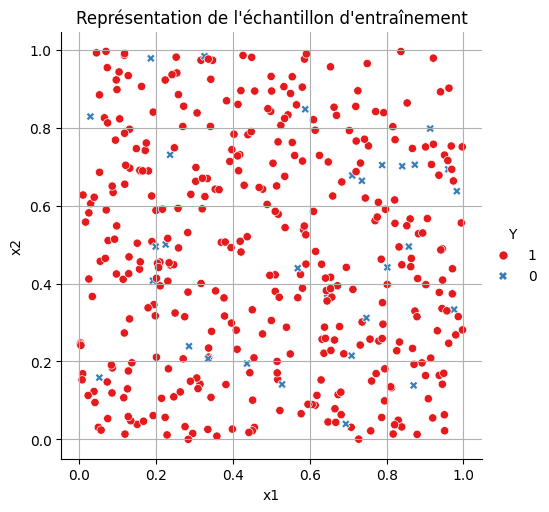

In [29]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Supposons que tu as Xtrain et Ytrain déjà prêts
# On les convertit en DataFrame pour seaborn

def afficher_relplot(X, Y):
    data = pd.DataFrame({
        'x1': X[:, 0],
        'x2': X[:, 1],
        'Y': Y.astype(str)  # Pour que seaborn colorie par classe
    })

    sns.relplot(
        data=data,
        x="x1", y="x2",
        hue="Y",         # Couleur selon la classe
        style="Y",       # Symbole différent aussi
        palette="Set1",
        height=5
    )
    plt.title("Représentation de l'échantillon d'entraînement")
    plt.grid(True)
    plt.show()

# Appel :
afficher_relplot(X_train, y_train)

In [ ]:
# Sans utiliser le module relplot de la librairie de seaborn

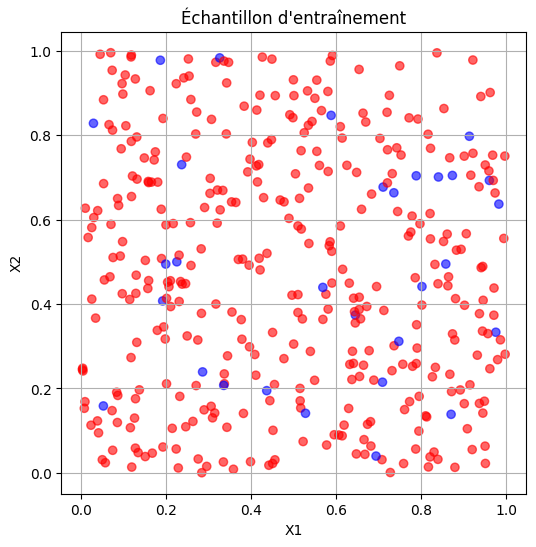

In [30]:
plt.figure(figsize=(6, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', alpha=0.6, label='Données')
plt.title("Échantillon d'entraînement")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.show()

In [31]:
# Question 4 :

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [34]:
# Entraîner le modèle k-NN avec k = 5

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

# Les deux points à prédire

points_a_predire = [[0.5, 0.5], [0.25, 0.75]]

# Faire la prédictions

predictions = knn.predict(points_a_predire)

# Afficher les résultats

for point, pred in zip(points_a_predire, predictions):
  print(f"point{point}=> Classe predite : {pred}")

point[0.5, 0.5]=> Classe predite : 1
point[0.25, 0.75]=> Classe predite : 1


In [35]:
# Question 5 :

In [39]:
for k in [1, 20]:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  ypred = knn.predict(X_test)

  accuracy = np.mean(ypred == y_test)
  print(f"Exactitude pour k={k}:  {accuracy:.2f}")

Exactitude pour k=1:  0.89
Exactitude pour k=20:  0.92


In [40]:
# Question 6 :

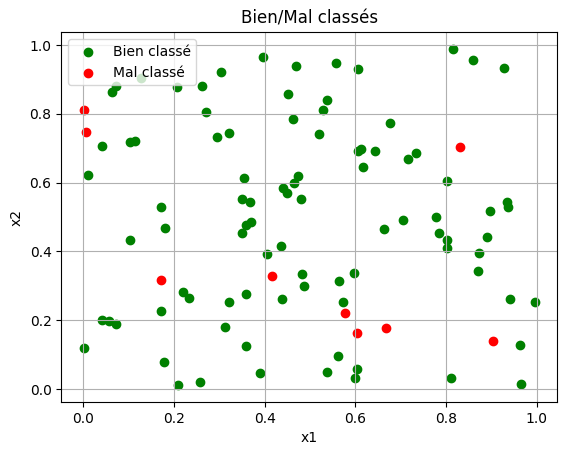

In [41]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
ypred = knn.predict(X_test)

correct = ypred == y_test
plt.scatter(X_test[correct,0], X_test[correct,1], c='green', label='Bien classé')
plt.scatter(X_test[~correct,0], X_test[~correct,1], c='red', label='Mal classé')
plt.legend()
plt.title("Bien/Mal classés")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

In [43]:
# Question 7 :

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

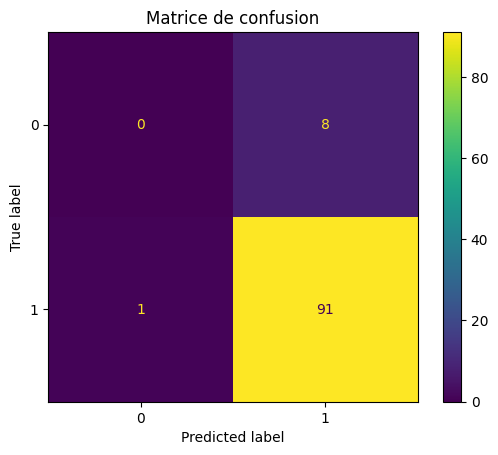

In [45]:
cm = confusion_matrix(y_test, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matrice de confusion")
plt.show()

In [46]:
# Question 8 :

In [47]:
error_rate = 1 - np.mean(ypred == y_test)
print(f"Erreur de classification : {error_rate:.2f}")

Erreur de classification : 0.09


In [48]:
# Question 9 :

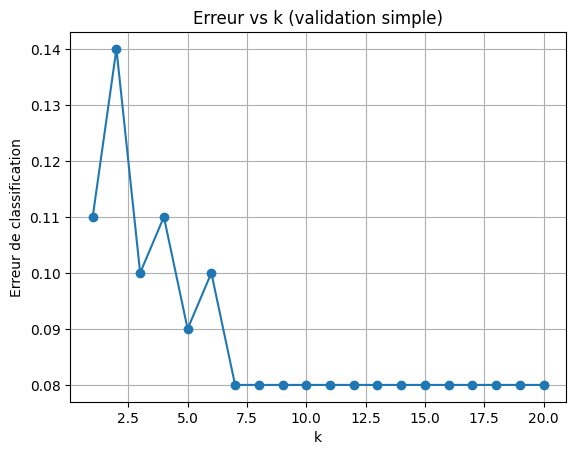

Meilleur k : 7


In [51]:
errors = []
k_range = range(1, 21)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    ypred = knn.predict(X_test)
    error = 1 - np.mean(ypred == y_test)
    errors.append(error)

plt.plot(k_range, errors, marker='o')
plt.title("Erreur vs k (validation simple)")
plt.xlabel("k")
plt.ylabel("Erreur de classification")
plt.grid(True)
plt.show()

best_k = k_range[np.argmin(errors)]
print(f"Meilleur k : {best_k}")

In [50]:
# Question 10 :

In [52]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
final_preds = knn.predict(X_test)
final_error = 1 - np.mean(final_preds == y_test)
print(f"Erreur finale sur test avec k optimal ({best_k}) : {final_error:.2f}")

Erreur finale sur test avec k optimal (7) : 0.08
